# GRIDWORLD B — MULTI AGENT (2 Agents, Independent Learners)

In [17]:
import numpy as np
import random
import matplotlib.pyplot as plt


class GridWorldBMultiAgent:
    def __init__(self, width, height, starts, goal, wind):
        self.width = width
        self.height = height
        self.starts = starts
        self.goal = goal
        self.wind = wind
        self.n_agents = len(starts)
        self.states = list(starts)
        self.agent_done = [False] * self.n_agents

    def reset(self):
        self.states = list(self.starts)
        self.agent_done = [False] * self.n_agents
        return list(self.states)

    def _move(self, pos, action):
        x, y = pos
        if action == 0: x = max(x - 1, 0)
        elif action == 1: x = min(x + 1, self.height - 1)
        elif action == 2: y = max(y - 1, 0)
        elif action == 3: y = min(y + 1, self.width - 1)
        x = max(x - self.wind[y], 0)
        return (x, y)

    def step(self, actions):
        desired = []
        for i in range(self.n_agents):
            if self.agent_done[i]:
                desired.append(self.states[i])  # freeze at goal
            else:
                desired.append(self._move(self.states[i], actions[i]))

        # Collision resolution: skip for already-done agents
        for i in range(self.n_agents):
            for j in range(i + 1, self.n_agents):
                if self.agent_done[i] or self.agent_done[j]:
                    continue
                if desired[i] == desired[j]:
                    loser = random.choice([i, j])
                    desired[loser] = self.states[loser]
                elif desired[i] == self.states[j] and desired[j] == self.states[i]:
                    loser = random.choice([i, j])
                    desired[loser] = self.states[loser]

        rewards = []
        for i in range(self.n_agents):
            if self.agent_done[i]:
                rewards.append(0)
            elif desired[i] == self.goal:
                rewards.append(1)
                self.agent_done[i] = True
            else:
                rewards.append(-1)

        self.states = desired
        done = all(self.agent_done)
        return list(self.states), rewards, done

## Algorithms

In [18]:
def epsilon_greedy_policy(Q, state, epsilon):
    if random.uniform(0, 1) < epsilon:
        return random.randint(0, 3)  # Explore: choose a random action
    else:
        q_values = Q[state[0], state[1]]
        max_q = np.max(q_values)
        best_actions = np.where(q_values == max_q)[0]
        return random.choice(best_actions)  # Exploit: choose the best action

In [19]:
def sarsa_multi(env, episodes, alpha, gamma, epsilon, max_steps=1000):
    Q = [np.zeros((env.height, env.width, 4)) for _ in range(env.n_agents)]
    steps_per_episode = []
    rewards_per_episode = []

    for episode in range(episodes):
        states = env.reset()
        actions = [epsilon_greedy_policy(Q[i], states[i], epsilon) for i in range(env.n_agents)]
        done = False
        total_reward = 0
        steps = 0

        while not done and steps < max_steps:
            next_states, rewards, done = env.step(actions)
            next_actions = [epsilon_greedy_policy(Q[i], next_states[i], epsilon) for i in range(env.n_agents)]

            for i in range(env.n_agents):
                Q[i][states[i][0], states[i][1], actions[i]] += alpha * (
                    rewards[i] + gamma * Q[i][next_states[i][0], next_states[i][1], next_actions[i]]
                    - Q[i][states[i][0], states[i][1], actions[i]]
                )

            states = next_states
            actions = next_actions
            total_reward += sum(rewards)
            steps += 1

        steps_per_episode.append(steps)
        rewards_per_episode.append(total_reward)

    return Q, steps_per_episode, rewards_per_episode

In [20]:
def evaluate_multi(env, Q, trials=100, max_steps=1000):
    steps_list = []
    for _ in range(trials):
        states = env.reset()
        done = False
        steps = 0
        while not done and steps < max_steps:
            actions = [epsilon_greedy_policy(Q[i], states[i], epsilon=0) for i in range(env.n_agents)]
            states, _, done = env.step(actions)
            steps += 1
        steps_list.append(steps)
    return np.mean(steps_list), np.std(steps_list)

In [21]:
def q_learning_multi(env, episodes, alpha, gamma, epsilon, max_steps=1000):
    Q = [np.zeros((env.height, env.width, 4)) for _ in range(env.n_agents)]
    steps_per_episode = []
    rewards_per_episode = []

    for episode in range(episodes):
        states = env.reset()
        actions = [epsilon_greedy_policy(Q[i], states[i], epsilon) for i in range(env.n_agents)]
        done = False
        total_reward = 0
        steps = 0

        while not done and steps < max_steps:
            next_states, rewards, done = env.step(actions)

            for i in range(env.n_agents):
                Q[i][states[i][0], states[i][1], actions[i]] += alpha * (
                    rewards[i] + gamma * np.max(Q[i][next_states[i][0], next_states[i][1]])
                    - Q[i][states[i][0], states[i][1], actions[i]]
                )

            states = next_states
            actions = [epsilon_greedy_policy(Q[i], states[i], epsilon) for i in range(env.n_agents)]
            total_reward += sum(rewards)
            steps += 1

        steps_per_episode.append(steps)
        rewards_per_episode.append(total_reward)

    return Q, steps_per_episode, rewards_per_episode

In [22]:
def double_q_learning_multi(env, episodes, alpha, gamma, epsilon, max_steps=1000):
    Q1 = [np.zeros((env.height, env.width, 4)) for _ in range(env.n_agents)]
    Q2 = [np.zeros((env.height, env.width, 4)) for _ in range(env.n_agents)]
    steps_per_episode = []
    rewards_per_episode = []

    for episode in range(episodes):
        states = env.reset()
        actions = [epsilon_greedy_policy(Q1[i] + Q2[i], states[i], epsilon) for i in range(env.n_agents)]
        done = False
        total_reward = 0
        steps = 0

        while not done and steps < max_steps:
            next_states, rewards, done = env.step(actions)

            for i in range(env.n_agents):
                if random.random() < 0.5:
                    best_action = np.argmax(Q1[i][next_states[i][0], next_states[i][1]])
                    Q1[i][states[i][0], states[i][1], actions[i]] += alpha * (
                        rewards[i] + gamma * Q2[i][next_states[i][0], next_states[i][1], best_action]
                        - Q1[i][states[i][0], states[i][1], actions[i]]
                    )
                else:
                    best_action = np.argmax(Q2[i][next_states[i][0], next_states[i][1]])
                    Q2[i][states[i][0], states[i][1], actions[i]] += alpha * (
                        rewards[i] + gamma * Q1[i][next_states[i][0], next_states[i][1], best_action]
                        - Q2[i][states[i][0], states[i][1], actions[i]]
                    )

            states = next_states
            actions = [epsilon_greedy_policy(Q1[i] + Q2[i], states[i], epsilon) for i in range(env.n_agents)]
            total_reward += sum(rewards)
            steps += 1

        steps_per_episode.append(steps)
        rewards_per_episode.append(total_reward)

    Q = [(Q1[i] + Q2[i]) / 2 for i in range(env.n_agents)]
    return Q, steps_per_episode, rewards_per_episode

In [23]:
def smooth(data, window=50):
    kernel = np.ones(window) / window
    return np.convolve(data, kernel, mode='valid')

def convergence_time(steps_per_episode, buffer=30, window=50):
    optimal = min(steps_per_episode)
    threshold = optimal + buffer
    smoothed = smooth(steps_per_episode, window)
    for i, val in enumerate(smoothed):
        if val <= threshold:
            return i + window
    return len(steps_per_episode)  # never converged

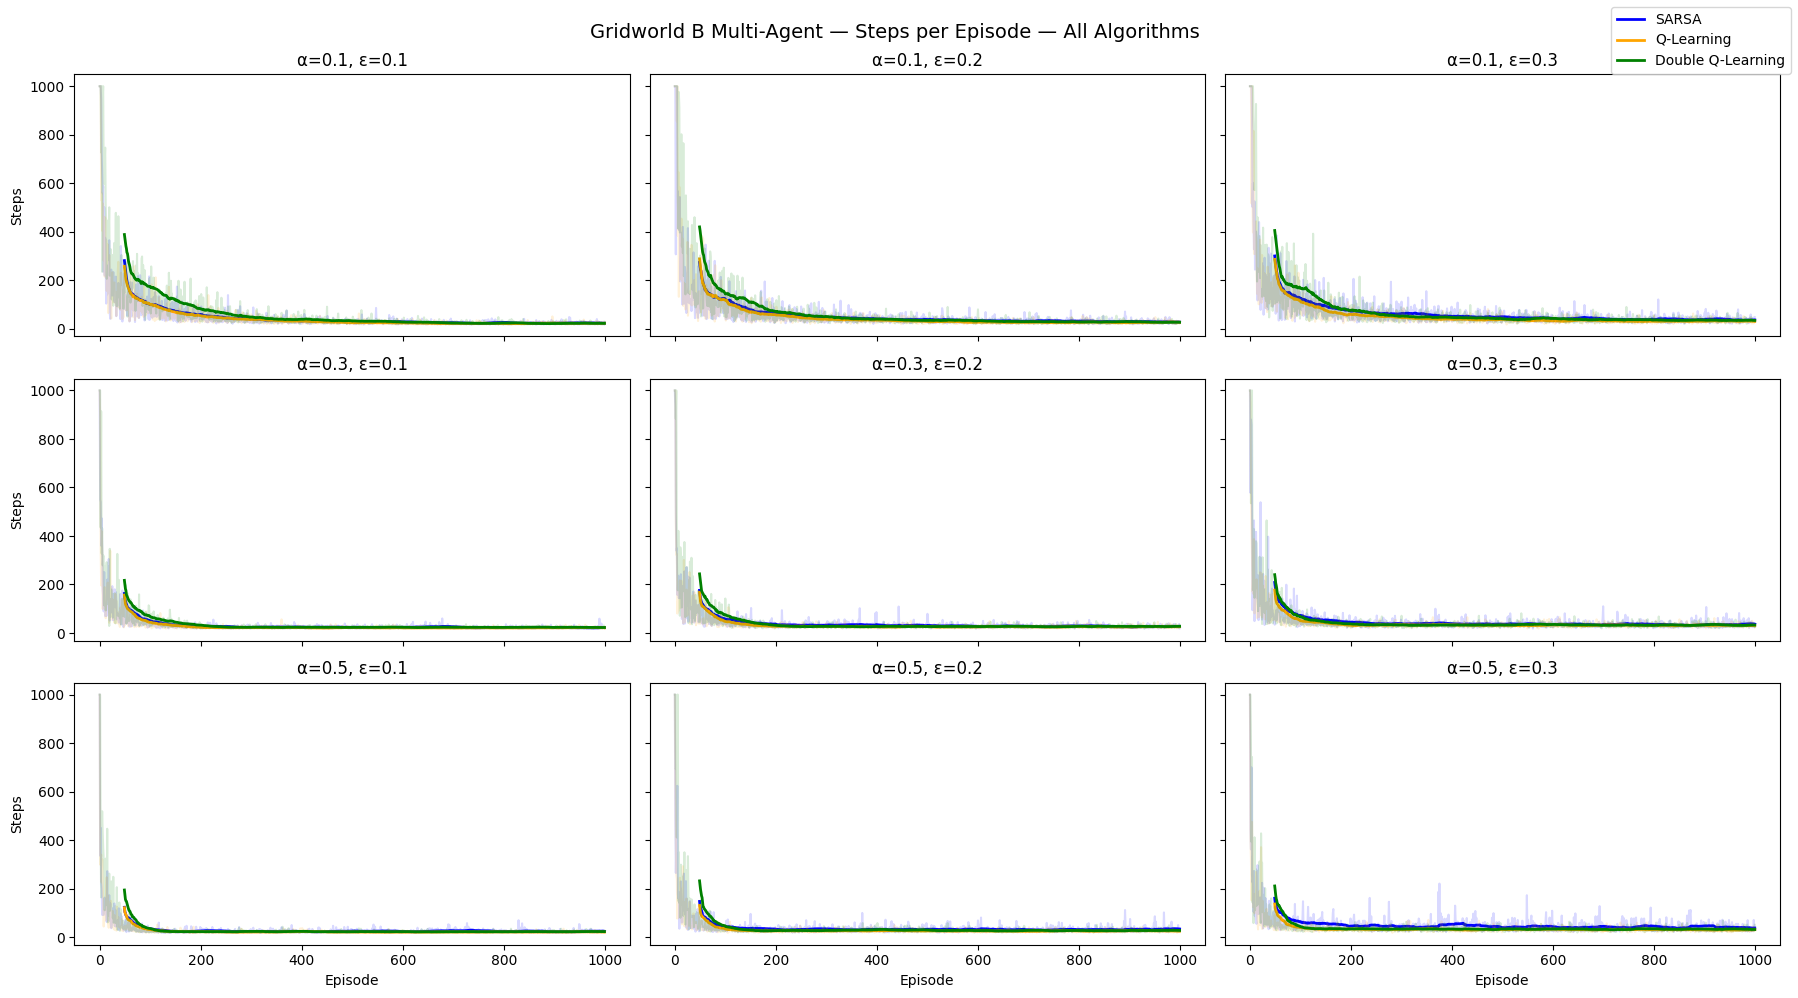

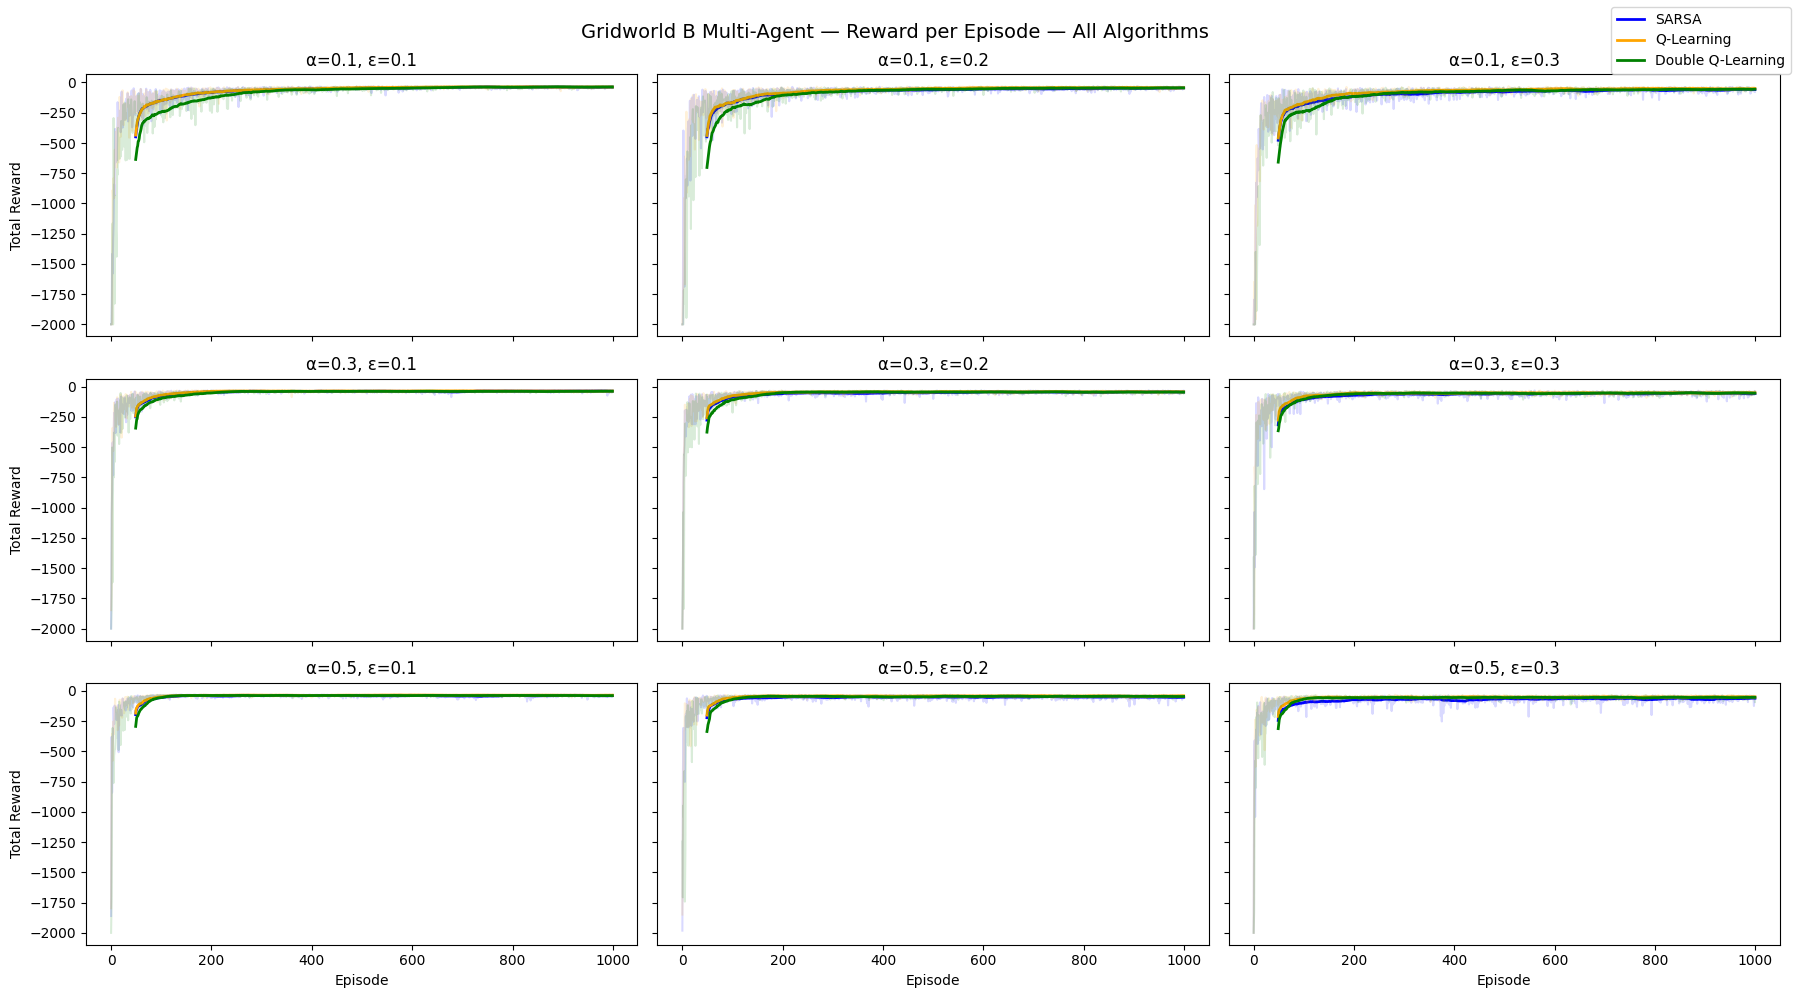

CONVERGENCE TIME (episode where rolling avg steps first drops to near-optimal)
Algorithm            α      ε       Conv. Episode
--------------------------------------------------
SARSA                0.1    0.1               238
SARSA                0.1    0.2               291
SARSA                0.1    0.3               400
SARSA                0.3    0.1               106
SARSA                0.3    0.2               132
SARSA                0.3    0.3               180
SARSA                0.5    0.1                79
SARSA                0.5    0.2                91
SARSA                0.5    0.3               187

Q-Learning           0.1    0.1               227
Q-Learning           0.1    0.2               244
Q-Learning           0.1    0.3               288
Q-Learning           0.3    0.1                95
Q-Learning           0.3    0.2               100
Q-Learning           0.3    0.3               106
Q-Learning           0.5    0.1                73
Q-Learning         

In [24]:
if __name__ == "__main__":

    width = 10
    height = 7
    starts = [(3, 0), (6, 0)]   # agent 1: middle-left, agent 2: bottom-left
    goal = (3, 7)
    wind = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]
    env = GridWorldBMultiAgent(width, height, starts, goal, wind)

    episodes = 1000
    gamma = 1.0  # undiscounted

    epsilons = [0.1, 0.2, 0.3]
    alphas = [0.1, 0.3, 0.5]

    algorithms = {
        "SARSA": sarsa_multi,
        "Q-Learning": q_learning_multi,
        "Double Q-Learning": double_q_learning_multi,
    }
    colors = {"SARSA": "blue", "Q-Learning": "orange", "Double Q-Learning": "green"}

    # --- Train all combinations ---
    results = {}
    for algo_name, algo_fn in algorithms.items():
        for alpha in alphas:
            for eps in epsilons:
                Q, steps, rewards = algo_fn(env, episodes, alpha=alpha, gamma=gamma, epsilon=eps)
                results[(algo_name, alpha, eps)] = (Q, steps, rewards)

    # --- Learning curves: Steps per episode (raw + smoothed) ---
    fig, axes = plt.subplots(len(alphas), len(epsilons), figsize=(18, 10), sharex=True, sharey=True)
    fig.suptitle("Gridworld B Multi-Agent — Steps per Episode — All Algorithms", fontsize=14)
    for i, alpha in enumerate(alphas):
        for j, eps in enumerate(epsilons):
            ax = axes[i][j]
            for algo_name in algorithms:
                _, steps, _ = results[(algo_name, alpha, eps)]
                ax.plot(steps, color=colors[algo_name], alpha=0.15)
                ax.plot(range(49, len(steps)), smooth(steps), color=colors[algo_name], linewidth=2, label=algo_name)
            ax.set_title(f"α={alpha}, ε={eps}")
            if i == len(alphas) - 1:
                ax.set_xlabel("Episode")
            if j == 0:
                ax.set_ylabel("Steps")
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    plt.tight_layout()
    plt.show()

    # --- Learning curves: Reward per episode (raw + smoothed) ---
    fig, axes = plt.subplots(len(alphas), len(epsilons), figsize=(18, 10), sharex=True, sharey=True)
    fig.suptitle("Gridworld B Multi-Agent — Reward per Episode — All Algorithms", fontsize=14)
    for i, alpha in enumerate(alphas):
        for j, eps in enumerate(epsilons):
            ax = axes[i][j]
            for algo_name in algorithms:
                _, _, rewards = results[(algo_name, alpha, eps)]
                ax.plot(rewards, color=colors[algo_name], alpha=0.15)
                ax.plot(range(49, len(rewards)), smooth(rewards), color=colors[algo_name], linewidth=2, label=algo_name)
            ax.set_title(f"α={alpha}, ε={eps}")
            if i == len(alphas) - 1:
                ax.set_xlabel("Episode")
            if j == 0:
                ax.set_ylabel("Total Reward")
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    plt.tight_layout()
    plt.show()

    # --- Convergence Time ---
    print("CONVERGENCE TIME (episode where rolling avg steps first drops to near-optimal)")
    print(f"{'Algorithm':<20} {'α':<6} {'ε':<6} {'Conv. Episode':>14}")
    print("-" * 50)
    for algo_name in algorithms:
        for alpha in alphas:
            for eps in epsilons:
                _, steps, _ = results[(algo_name, alpha, eps)]
                conv = convergence_time(steps)
                print(f"{algo_name:<20} {alpha:<6} {eps:<6} {conv:>14}")
        print()

    # --- Path Efficiency ---
    print("\nPATH EFFICIENCY (avg steps over 100 greedy trials after training)")
    print(f"{'Algorithm':<20} {'α':<6} {'ε':<6} {'Avg Steps':>10}")
    print("-" * 46)
    for algo_name in algorithms:
        for alpha in alphas:
            for eps in epsilons:
                Q, _, _ = results[(algo_name, alpha, eps)]
                mean, _ = evaluate_multi(env, Q)
                print(f"{algo_name:<20} {alpha:<6} {eps:<6} {mean:>10.2f}")
        print()

    # --- Robustness (multiple seeds) ---
    n_seeds = 10
    print("\nROBUSTNESS (std dev of avg steps across 10 training seeds)")
    print(f"{'Algorithm':<20} {'α':<6} {'ε':<6} {'Avg Steps':>10} {'Std Dev':>10}")
    print("-" * 58)
    for algo_name, algo_fn in algorithms.items():
        for alpha in alphas:
            for eps in epsilons:
                seed_means = []
                for seed in range(n_seeds):
                    random.seed(seed)
                    np.random.seed(seed)
                    Q, _, _ = algo_fn(env, episodes, alpha=alpha, gamma=gamma, epsilon=eps)
                    mean, _ = evaluate_multi(env, Q)
                    seed_means.append(mean)
                print(f"{algo_name:<20} {alpha:<6} {eps:<6} {np.mean(seed_means):>10.2f} {np.std(seed_means):>10.2f}")
        print()